# STEP 2 · 需求面与现状错配

SoC 蒙特卡洛 → 低电量需求面（节点中心，node_id 主键）→ 低电量需求可视化 → 现状 M(F) 分解 → 站点负载/拥挤/可达性。

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'        # 城市配置键；换城市改这里
CITY_CONFIG = ''          # 可选：外部 city_configs.json 路径
MODE = 'truncated'        # 现状口径：'truncated'(观测期前已建) 或 'comprehensive'(全部现存)
NOTEBOOK_SMOKE = False     # True=少抽样/少天数，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
OUT = cso.OUTPUT_ROOT / cso.CITY / 'notebook_step2'   # 图件输出（独立子目录，不覆盖正式 Outputs）
OUT.mkdir(parents=True, exist_ok=True)
print(f'城市 {cso.CITY_NAME}({cso.CITY}) | 口径 {MODE} | 抽样 {DRAWS} | 发现 {len(cso.DAYS)} 天')
print(f'参数 C_BAR={cso.C_BAR} d0={cso.D0_DECAY} gamma={cso.GAMMA} u={cso.SYS_UTIL} beta={cso.BETA_CROWD} P_DEAD={cso.P_DEAD}')
print('图件输出目录:', OUT)

城市 广州(guangzhou) | 口径 truncated | 抽样 40 | 发现 7 天
参数 C_BAR=100.0 d0=8.0 gamma=10.0 u=1.0 beta=1.0 P_DEAD=1000.0
图件输出目录: D:\Desktop\香港大学\20260521 根据网约车轨迹优化充电站\ChargingStationOptimization\Outputs\guangzhou\notebook_step2


## 2.1 抽样检查车 SoC 曲线（按一天总耗电分位选车）

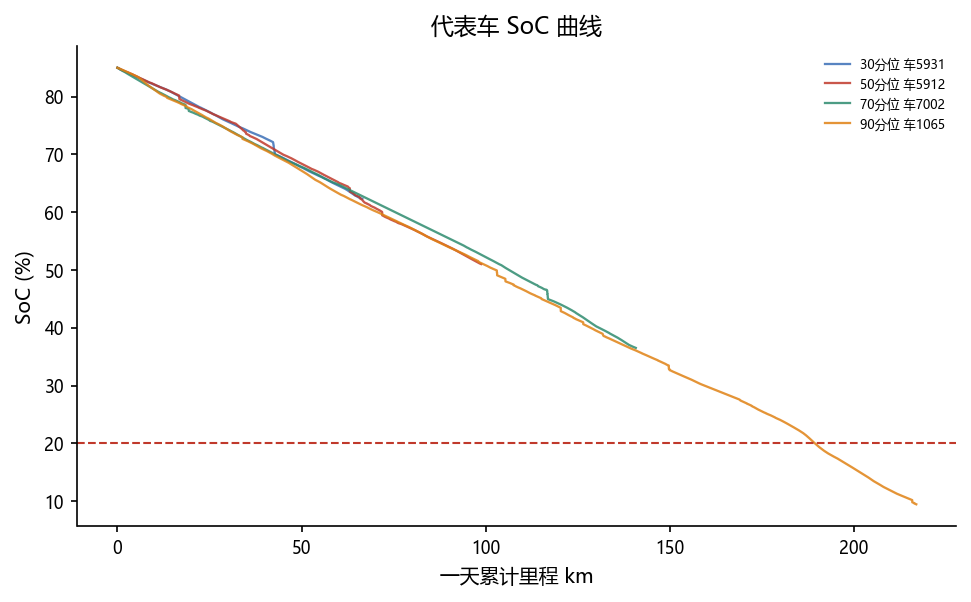

In [2]:
ex = cso.simulate_soc_examples(percentiles=(30, 50, 70, 90))
fig, ax = plt.subplots(figsize=style.mm(120, 66))
for e in ex:
    ax.plot(e['cum_km'], e['soc'] * 100, lw=1.1, alpha=0.85, label=f"{e['pct']}分位 车{e['veh']}")
ax.axhline(cso.SOC_LOW * 100, color=style.C['red'], ls='--', lw=1)
ax.set_xlabel('一天累计里程 km'); ax.set_ylabel('SoC (%)'); ax.set_title('代表车 SoC 曲线'); ax.legend(fontsize=6)
style.savefig(fig, OUT / 'fig_soc_curves.png'); plt.show()

## 2.2 低电量需求面

In [3]:
D = cso.build_demand_surface(draws=DRAWS)
w = D['w']
print(f'需求表示: {D["space"]} | 需求节点 {D["n_cells"]} | 期望低电量事件合计 {w.sum():.0f} 次/天 | 天数 {D["n_days"]}')

[OSMnx] 载入缓存路网图 _graph_guangzhou.graphml ...
[OSMnx] 路网图就绪：75,488 节点，166,968 边


需求面·7天×40抽样(路网节点中心):   0%|          | 0/7 [00:00<?, ?it/s]

需求表示: node | 需求节点 42450 | 期望低电量事件合计 4598 次/天 | 天数 7


## 2.3 低电量需求可视化
需求已 snap 到路网节点，用 `node_id` 关联路段、取两端 `max(w_u,w_v)` 着色；无需求路段画浅灰底图。

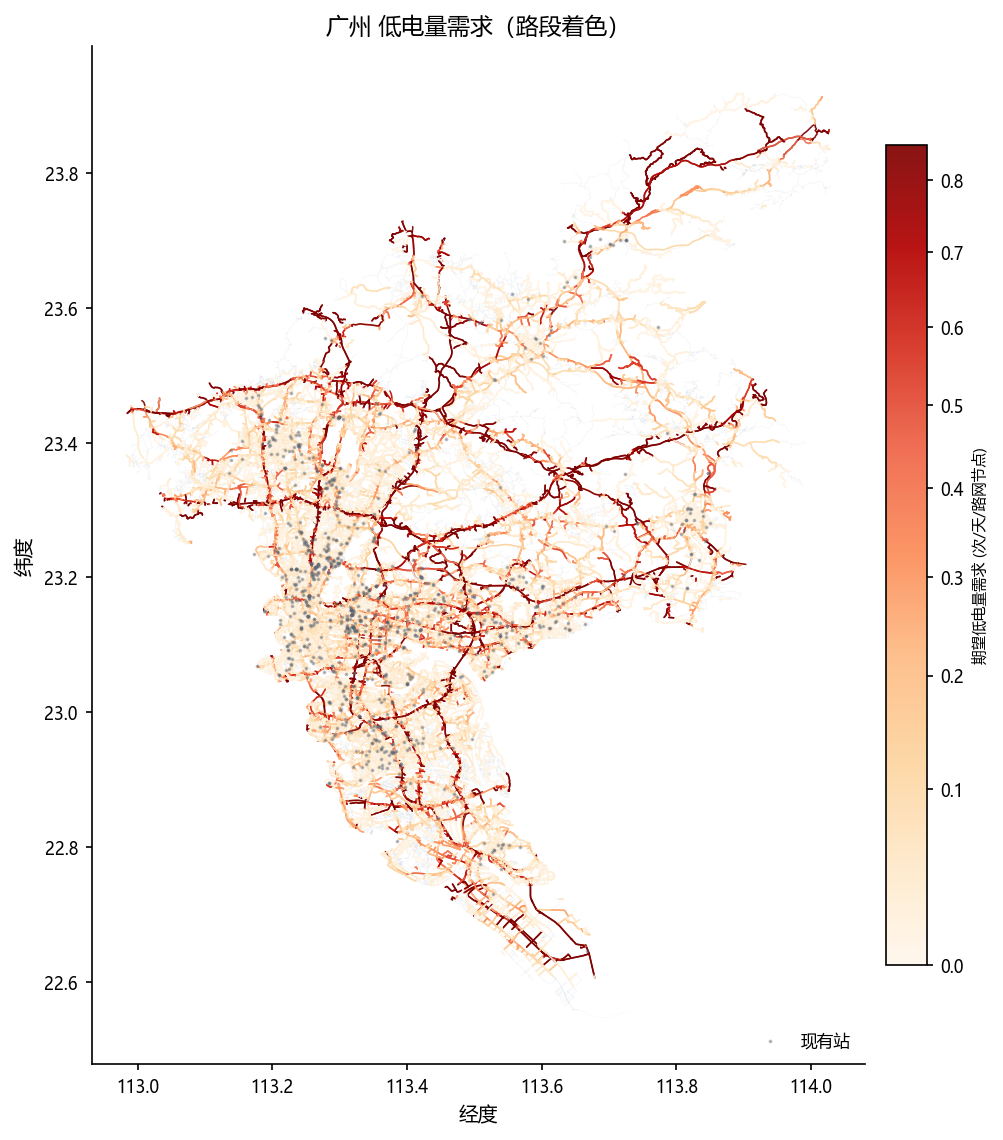

In [4]:
st = cso.load_stations(MODE)
fig, ax = plt.subplots(figsize=style.mm(140, 140))
lc = cso.plot_demand_network(ax, D, slon=st['lon'].to_numpy(), slat=st['lat'].to_numpy(),
                             title=f'{cso.CITY_NAME} 低电量需求（路段着色）')
if lc is not None:
    cb = fig.colorbar(lc, ax=ax, fraction=0.04, pad=0.02); cb.set_label('期望低电量需求 (次/天/路网节点)', fontsize=7)
ax.legend(loc='lower right')
style.savefig(fig, OUT / 'fig_demand_network.png'); plt.show()

## 2.4 现状错配 M 分解 + M(F) 分解
`M_reach` 是 P_DEAD 折算量； M(F) 分解可达覆盖率/不可达占比。

[路网] 把 42450 需求点 + 873 站点 snap 到路网节点...


scipy最短路·738个站点节点(cutoff 100km):   0%|          | 0/12 [00:00<?, ?it/s]

M_old(零拥挤参照) = 73668
M_2SFCA = 113950 = access 55638 + crowd 5305 + reach 53007
M(F)分解: 可达覆盖率 0.988 | 不可达需求点 185 | 不可达需求量 53 (1.2%)
拥挤度 C: 中位 0.79 90分位 2.57 | 超容量站 263/873


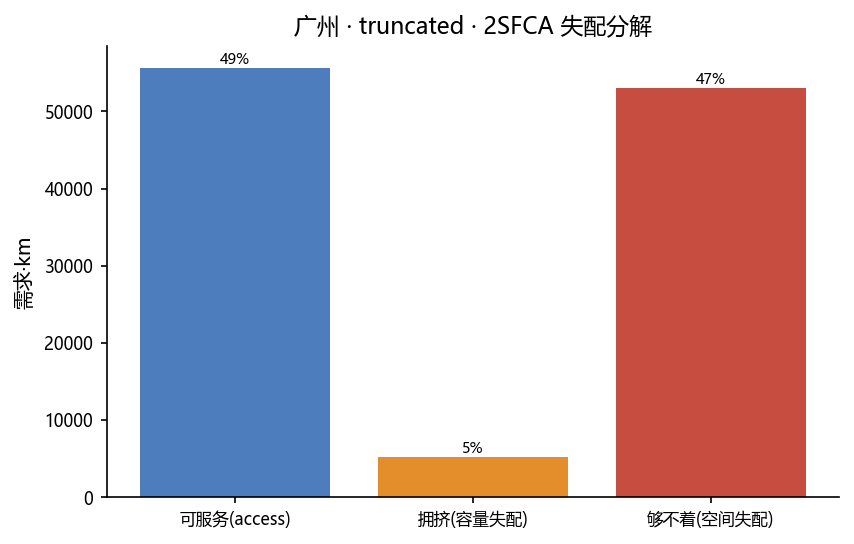

In [5]:
slon, slat = st['lon'].to_numpy(), st['lat'].to_numpy()
fast, slow = st['fast'].to_numpy(), st['slow'].to_numpy()
c = cso.dist_matrix(D['lon_c'], D['lat_c'], slon, slat)
s_fix = cso._disp_scale(w, fast, slow)
b = cso.baseline_report(w, c, fast, slow, s=s_fix)
print(f"M_old(零拥挤参照) = {b['M_old']:.0f}")
print(f"M_2SFCA = {b['M']:.0f} = access {b['M_access']:.0f} + crowd {b['M_crowd']:.0f} + reach {b['M_reach']:.0f}")
print(f"M(F)分解: 可达覆盖率 {b['reach_cov']:.3f} | 不可达需求点 {b['n_unreach']} | 不可达需求量 {b['w_unreach']:.0f} ({b['unreach_frac']*100:.1f}%)")
print(f"拥挤度 C: 中位 {b['C_med']:.2f} 90分位 {b['C_p90']:.2f} | 超容量站 {b['over_cap']}/{len(st)}")
fig, ax = plt.subplots(figsize=style.mm(100, 62))
lab = ['可服务(access)', '拥挤(容量失配)', '够不着(空间失配)']; val = [b['M_access'], b['M_crowd'], b['M_reach']]
ax.bar(lab, val, color=[style.C['blue'], style.C['orange'], style.C['red']], alpha=0.9)
for i, vv in enumerate(val):
    ax.text(i, vv, f'{vv/max(sum(val),1e-9)*100:.0f}%', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('需求·km'); ax.set_title(f'{cso.CITY_NAME} · {MODE} · 2SFCA 失配分解')
style.savefig(fig, OUT / 'fig_mismatch_decomp.png'); plt.show()

## 2.5 站点负载 $L_j$ / 拥挤度 $C_j$ / 负载密度分布
$p_{ij}=\frac{b_j\,G_{ij}}{\sum_{k}b_k\,G_{ik}},\qquad L_j=\sum_iw_i\,p_{ij},\qquad C_j=\frac{L_j}{b_j}>1$ 表示该站在 2SFCA 分配下存在超额竞争。

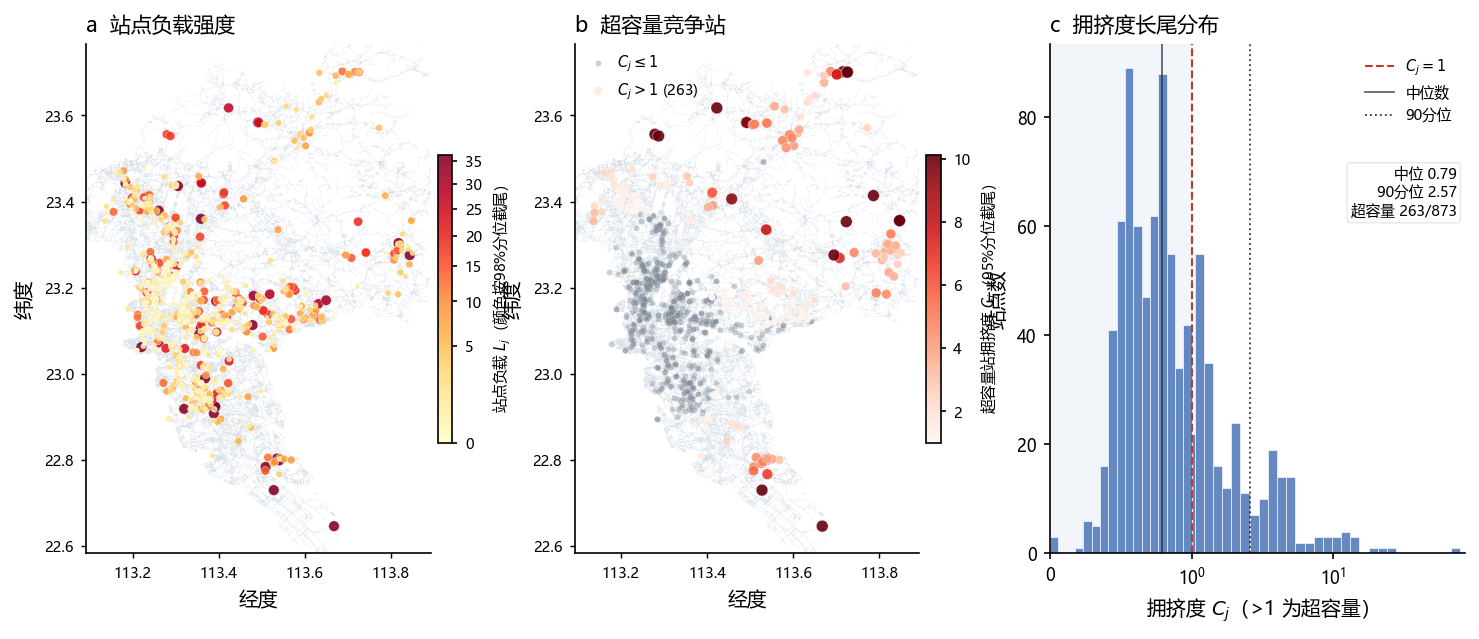

In [6]:
slr = cso.station_load_report(w, c, fast, slow, s=s_fix, sid=st['sid'].to_numpy(), slon=slon, slat=slat)
L = np.asarray(slr['L'], float)
Cj = np.asarray(slr['C'], float)
over = np.asarray(slr['is_over'], bool)

# 两个地图面板使用同一范围；边界留少量空白，避免站点贴边，同时保持两个空间判断可比。
x_pad = max((float(np.nanmax(slon)) - float(np.nanmin(slon))) * 0.06, 0.035)
y_pad = max((float(np.nanmax(slat)) - float(np.nanmin(slat))) * 0.06, 0.035)
xlim = (max(cso.BBOX['lon_min'], float(np.nanmin(slon)) - x_pad),
        min(cso.BBOX['lon_max'], float(np.nanmax(slon)) + x_pad))
ylim = (max(cso.BBOX['lat_min'], float(np.nanmin(slat)) - y_pad),
        min(cso.BBOX['lat_max'], float(np.nanmax(slat)) + y_pad))

fig, ax = plt.subplots(1, 3, figsize=style.mm(190, 70),
                       gridspec_kw={'width_ratios': [1.05, 1.05, 1.15], 'wspace': 0.28})


def _draw_base(axi):
    """淡灰路网只承担空间参照，不参与颜色竞争；若 OSMnx 不可用则退回行政边界。"""
    ok = style.draw_network(axi, cache_dir=cso.DATA, city=cso.CITY,
                            color='#D9E1EA', lw=0.16, alpha=0.42)
    if not ok:
        style.draw_admin(axi, cache_dir=cso.DATA, adcode=cso.CITY_ADMIN_ADCODE,
                         color='#B8C0CC', lw=0.45)
    axi.set_xlim(*xlim); axi.set_ylim(*ylim)
    axi.set_aspect('equal', adjustable='box')
    axi.set_xlabel('经度'); axi.set_ylabel('纬度')
    axi.tick_params(labelsize=7, length=2.5, width=0.7)


# (a) 站点负载：颜色和点大小同时表达 L_j；色阶按 98% 分位截尾，避免极端负载压扁主体差异。
_draw_base(ax[0])
L98 = max(float(np.nanpercentile(L, 98)), 1e-9)
L_plot = np.clip(L, 0, L98)
size_L = 2 + 24 * np.sqrt(L_plot / L98)
sc0 = ax[0].scatter(slon, slat, s=size_L, c=L_plot, cmap='YlOrRd',
                    norm=mcolors.PowerNorm(gamma=0.55, vmin=0, vmax=L98),
                    alpha=0.88, edgecolors='white', linewidths=0.18, zorder=3)
cb0 = fig.colorbar(sc0, ax=ax[0], fraction=0.038, pad=0.018)
cb0.set_label('站点负载 $L_j$（颜色按98%分位截尾）', fontsize=7)
cb0.ax.tick_params(labelsize=7, length=2.5)
ax[0].set_title('a  站点负载强度', loc='left', fontsize=10)

# (b) 拥挤站：正常站作为弱参照，超容量站用红色和尺寸突出，减少旧图里红灰点同权造成的拥挤感。
_draw_base(ax[1])
ax[1].scatter(slon[~over], slat[~over], s=8, c='#7B8794', alpha=0.38,
              edgecolors='white', linewidths=0.12, zorder=3, label='$C_j \\leq 1$')
C_over = Cj[over]
if C_over.size:
    C95 = max(float(np.nanpercentile(C_over, 95)), 1.01)
    C_plot = np.clip(C_over, 1.0, C95)
    size_C = 4 + 28 * np.sqrt((C_plot - 1.0) / max(C95 - 1.0, 1e-9))
    sc1 = ax[1].scatter(slon[over], slat[over], s=size_C, c=C_plot, cmap='Reds',
                        norm=mcolors.Normalize(vmin=1.0, vmax=C95), alpha=0.90,
                        edgecolors='white', linewidths=0.18, zorder=4,
                        label=f'$C_j>1$ ({int(over.sum())})')
    cb1 = fig.colorbar(sc1, ax=ax[1], fraction=0.038, pad=0.018)
    cb1.set_label('超容量站拥挤度 $C_j$（95%分位截尾）', fontsize=7)
    cb1.ax.tick_params(labelsize=7, length=2.5)
ax[1].legend(loc='upper left', fontsize=7, handletextpad=0.3, borderaxespad=0.2)
ax[1].set_title('b  超容量竞争站', loc='left', fontsize=10)

# (c) 拥挤度分布：0-1 区间保持线性，>1 的长尾用 symlog 压缩，便于同时读主体和极端拥挤站。
C_valid = Cj[np.isfinite(Cj) & (Cj >= 0)]
C_max = max(float(np.nanmax(C_valid)), 1.05)
lin_bins = np.linspace(0, 1, 18)
log_bins = np.geomspace(1.05, C_max * 1.001, 30) if C_max > 1.05 else np.array([1.05])
bins = np.unique(np.r_[lin_bins, log_bins])
ax[2].hist(C_valid, bins=bins, color='#4D76B8', alpha=0.86,
           edgecolor='white', linewidth=0.35)
ax[2].set_xscale('symlog', linthresh=1.0, linscale=0.9)
ax[2].axvspan(0, 1, color='#E8EEF5', alpha=0.55, zorder=0)
ax[2].axvline(1.0, color=style.C['red'], ls='--', lw=1.0, label='$C_j=1$')
ax[2].axvline(float(np.nanmedian(C_valid)), color='#1A2230', ls='-', lw=0.8, alpha=0.75, label='中位数')
ax[2].axvline(float(np.nanpercentile(C_valid, 90)), color='#1A2230', ls=':', lw=0.9, alpha=0.85, label='90分位')
ax[2].set_xlim(0, C_max * 1.08)
ax[2].set_xlabel('拥挤度 $C_j$（>1 为超容量）')
ax[2].set_ylabel('站点数')
ax[2].set_title('c  拥挤度长尾分布', loc='left', fontsize=10)
ax[2].legend(loc='upper right', fontsize=7, frameon=False)
ax[2].text(0.98, 0.76,
           f"中位 {np.nanmedian(C_valid):.2f}\n90分位 {np.nanpercentile(C_valid, 90):.2f}\n超容量 {int(over.sum())}/{len(Cj)}",
           transform=ax[2].transAxes, ha='right', va='top', fontsize=7,
           bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#D9DEE5', lw=0.5, alpha=0.92))

style.savefig(fig, OUT / 'fig_station_load.png')
plt.show()
